In [83]:
import pandas as pd
import numpy as np

In [84]:
df=pd.read_csv(r'C:\Users\ADMIN\OneDrive\Desktop\5thsem_OJT\project1_diabetes\data\processed\project1_diabetes_cleaned.csv',parse_dates=["last_checkup_date"])

In [85]:
df.head(10)

,patient_id,age,gender,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,physical_activity,smoker,last_checkup_date,outcome
0,P00826,79,male,0,124.0,71.0,30.0,124.0,23.4,0.588,Unknown,NO,2023-04-20,0
1,P00108,37,male,0,153.0,85.0,24.0,42.0,33.9,0.192,Medium,YES,2024-05-03,1
2,P00517,39,female,0,142.0,68.0,22.0,159.0,26.9,0.777,Low,UNKNOWN,2023-07-08,0
3,P00687,68,female,7,121.0,88.0,26.0,124.0,29.0,1.217,Unknown,YES,2024-04-14,1
4,P00927,75,female,0,107.0,84.0,31.0,101.0,21.2,0.278,Low,NO,2024-01-27,0
5,P00755,37,female,0,145.0,80.0,26.0,124.0,22.0,0.488,High,YES,2024-01-10,0
6,P00431,58,male,5,95.0,72.0,26.0,170.0,27.2,0.197,High,NO,2023-12-25,0
7,P00542,58,female,3,150.0,68.0,17.0,124.0,46.0,0.808,Medium,NO,2024-06-20,1
8,P00929,32,female,6,129.0,74.0,26.0,226.0,20.6,0.655,High,UNKNOWN,2023-10-15,1
9,P00513,61,female,0,161.0,77.0,35.0,201.0,35.0,1.229,Medium,YES,2023-12-22,1


In [86]:
df.shape

(950, 14)

In [87]:
df.dtypes

patient_id                      str
age                           int64
gender                          str
pregnancies                   int64
glucose                     float64
blood_pressure              float64
skin_thickness              float64
insulin                     float64
bmi                         float64
diabetes_pedigree           float64
physical_activity               str
smoker                          str
last_checkup_date    datetime64[us]
outcome                       int64
dtype: object

CREATE AND AGE BAND FEATURE

In [88]:
df['age band']=pd.cut(df['age'],
bins=[0,35,55,120],
labels=['under 35','35-55','over 55'])

In [89]:
df.head()

,patient_id,age,gender,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,physical_activity,smoker,last_checkup_date,outcome,age band
0,P00826,79,male,0,124.0,71.0,30.0,124.0,23.4,0.588,Unknown,NO,2023-04-20,0,over 55
1,P00108,37,male,0,153.0,85.0,24.0,42.0,33.9,0.192,Medium,YES,2024-05-03,1,35-55
2,P00517,39,female,0,142.0,68.0,22.0,159.0,26.9,0.777,Low,UNKNOWN,2023-07-08,0,35-55
3,P00687,68,female,7,121.0,88.0,26.0,124.0,29.0,1.217,Unknown,YES,2024-04-14,1,over 55
4,P00927,75,female,0,107.0,84.0,31.0,101.0,21.2,0.278,Low,NO,2024-01-27,0,over 55


create a bmi category features 

In [90]:
df['bmi category']=pd.cut(df['bmi'],
bins=[0,18.5,25,30,100],
labels=['under weights','normal','over weight','obese'])

In [91]:
df['bmi category'].value_counts()

bmi category
obese            553
over weight      235
normal           124
under weights     38
Name: count, dtype: int64

In [92]:
df['glucose category']=pd.cut(df['glucose'],
bins=[0,100,126,300],
labels=['normal','prediabetic','diabetic'])

In [93]:
df['glucose category'].value_counts()

glucose category
diabetic       349
prediabetic    337
normal         264
Name: count, dtype: int64

create a insulin-glucose ratio

In [94]:
df['insulin_glucose_ratio']=df['insulin']/df['glucose']

In [95]:
df['insulin_glucose_ratio'].head()

0    1.000000
1    0.274510
2    1.119718
3    1.024793
4    0.943925
Name: insulin_glucose_ratio, dtype: float64

In [96]:
df['insulin_glucose_ratio'].describe()

count    950.000000
mean       1.213361
std        1.179203
min        0.054348
25%        0.727225
50%        1.059829
75%        1.512831
max       22.745763
Name: insulin_glucose_ratio, dtype: float64

check ratio for impossible value

In [97]:
 df['insulin_glucose_ratio'].describe()
 np.isinf(df['insulin_glucose_ratio']).sum()

np.int64(0)

CREATE A PREGNANCIES PER YEAR OF AGE FEATURE

In [98]:
df['pregnancy_rate']=df['pregnancies']/df['age']

In [99]:
df.describe()

,age,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,last_checkup_date,outcome,insulin_glucose_ratio,pregnancy_rate
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950,950.000000,950.000000,950.000000
mean,49.864211,1.853684,117.841053,72.229474,26.277895,131.748421,31.394105,0.461863,2024-01-08 00:45:28.421052,0.287368,1.213361,0.042787
min,21.000000,0.000000,50.000000,40.000000,5.000000,10.000000,15.000000,0.050000,2023-01-03 00:00:00,0.000000,0.054348,0.000000
25%,35.000000,0.000000,98.000000,65.000000,21.000000,91.000000,26.800000,0.244250,2023-07-15 00:00:00,0.000000,0.727225,0.000000
50%,50.000000,0.000000,117.000000,72.000000,26.000000,124.000000,31.100000,0.445500,2024-01-11 00:00:00,0.000000,1.059829,0.000000
75%,65.000000,4.000000,136.000000,79.750000,31.000000,160.000000,35.275000,0.654750,2024-07-09 06:00:00,1.000000,1.512831,0.072661
max,81.000000,8.000000,215.000000,107.000000,67.000000,1399.000000,94.500000,1.532000,2024-12-28 00:00:00,1.000000,22.745763,0.380952
std,17.487840,2.622080,28.058178,11.520723,8.945134,102.018980,8.162011,0.285111,NaN,0.452773,1.179203,0.067440


In [100]:
referance_date=df['last_checkup_date'].max()

In [101]:
df['days_since_checkup']= (referance_date - df['last_checkup_date']).dt.days

create a categorical combination feature

In [102]:
df['activity_smoker']=df['physical_activity']+'/'+df['smoker']

check the combination features balance

In [103]:
df['activity_smoker'].value_counts()

activity_smoker
Medium/NO          207
High/NO            195
Low/NO             180
Low/YES             93
Medium/YES          90
High/YES            85
Unknown/NO          36
High/UNKNOWN        22
Unknown/YES         17
Medium/UNKNOWN      12
Low/UNKNOWN          9
Unknown/UNKNOWN      4
Name: count, dtype: int64

In [104]:
# activity smoker = physical_activity + smoker
# age band = age
# bmi category = bmi
# glucose category = glucose
# insulin glucose ratio = insulin/glucose
# pregnancy rate = pregnancies/age
# days since checkup = reference_date - last_checkup_date

In [105]:
df.shape

(950, 21)

## EXPLORATORY ANALYSIS

In [106]:
numeric_col=(['age','pregnancies','glucose','blood_pressure','skin_thickness','insulin','bmi','diabetes_pedigree'])
df.groupby('outcome')[numeric_col].mean()

,age,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree
outcome,,,,,,,,
0,47.874446,1.828656,112.193501,72.350074,26.370753,131.490399,30.941359,0.441821
1,54.798535,1.915751,131.846154,71.930403,26.047619,132.388278,32.516850,0.511564


In [107]:
engineered_numeric=['insulin_glucose_ratio','pregnancy_rate','days_since_checkup']
df.groupby('outcome')[engineered_numeric].mean()

,insulin_glucose_ratio,pregnancy_rate,days_since_checkup
outcome,,,
0,1.271313,0.044392,350.304284
1,1.069647,0.038809,366.534799


In [108]:
group_means=df.groupby("outcome")[numeric_col+engineered_numeric].mean().T
group_means["gap"]=(group_means[1] - group_means[0]).abs()
group_means.sort_values("gap",ascending=False)

outcome,0,1,gap
glucose,112.193501,131.846154,19.652653
days_since_checkup,350.304284,366.534799,16.230515
age,47.874446,54.798535,6.924089
bmi,30.941359,32.516850,1.575491
insulin,131.490399,132.388278,0.897880
blood_pressure,72.350074,71.930403,0.419671
skin_thickness,26.370753,26.047619,0.323134
insulin_glucose_ratio,1.271313,1.069647,0.201667
pregnancies,1.828656,1.915751,0.087095
diabetes_pedigree,0.441821,0.511564,0.069743


STATE THE NEW TOP THERE

In [109]:
#GLUCOSE
#days_since_checkup
#age

In [110]:
pd.crosstab(df['age band'],df['outcome'],normalize='index')

outcome,0,1
age band,,
under 35,0.789683,0.210317
35-55,0.766871,0.233129
over 55,0.612903,0.387097


In [111]:
df.head(15)

,patient_id,age,gender,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,...,smoker,last_checkup_date,outcome,age band,bmi category,glucose category,insulin_glucose_ratio,pregnancy_rate,days_since_checkup,activity_smoker
0,P00826,79,male,0,124.0,71.0,30.0,124.0,23.4,0.588,...,NO,2023-04-20,0,over 55,normal,prediabetic,1.000000,0.000000,618,Unknown/NO
1,P00108,37,male,0,153.0,85.0,24.0,42.0,33.9,0.192,...,YES,2024-05-03,1,35-55,obese,diabetic,0.274510,0.000000,239,Medium/YES
2,P00517,39,female,0,142.0,68.0,22.0,159.0,26.9,0.777,...,UNKNOWN,2023-07-08,0,35-55,over weight,diabetic,1.119718,0.000000,539,Low/UNKNOWN
3,P00687,68,female,7,121.0,88.0,26.0,124.0,29.0,1.217,...,YES,2024-04-14,1,over 55,over weight,prediabetic,1.024793,0.102941,258,Unknown/YES
4,P00927,75,female,0,107.0,84.0,31.0,101.0,21.2,0.278,...,NO,2024-01-27,0,over 55,normal,prediabetic,0.943925,0.000000,336,Low/NO
5,P00755,37,female,0,145.0,80.0,26.0,124.0,22.0,0.488,...,YES,2024-01-10,0,35-55,normal,diabetic,0.855172,0.000000,353,High/YES
6,P00431,58,male,5,95.0,72.0,26.0,170.0,27.2,0.197,...,NO,2023-12-25,0,over 55,over weight,normal,1.789474,0.086207,369,High/NO
7,P00542,58,female,3,150.0,68.0,17.0,124.0,46.0,0.808,...,NO,2024-06-20,1,over 55,obese,diabetic,0.826667,0.051724,191,Medium/NO
8,P00929,32,female,6,129.0,74.0,26.0,226.0,20.6,0.655,...,UNKNOWN,2023-10-15,1,under 35,normal,diabetic,1.751938,0.187500,440,High/UNKNOWN
9,P00513,61,female,0,161.0,77.0,35.0,201.0,35.0,1.229,...,YES,2023-12-22,1,over 55,obese,diabetic,1.248447,0.000000,372,Medium/YES


cross-tabulate the bmi category aganist outcome

In [112]:
pd.crosstab(df['bmi category'],df['outcome'],normalize='index')

outcome,0,1
bmi category,,
under weights,0.763158,0.236842
normal,0.750000,0.250000
over weight,0.770213,0.229787
obese,0.676311,0.323689


In [113]:
df.head()

,patient_id,age,gender,pregnancies,glucose,blood_pressure,skin_thickness,insulin,bmi,diabetes_pedigree,...,smoker,last_checkup_date,outcome,age band,bmi category,glucose category,insulin_glucose_ratio,pregnancy_rate,days_since_checkup,activity_smoker
0,P00826,79,male,0,124.0,71.0,30.0,124.0,23.4,0.588,...,NO,2023-04-20,0,over 55,normal,prediabetic,1.000000,0.000000,618,Unknown/NO
1,P00108,37,male,0,153.0,85.0,24.0,42.0,33.9,0.192,...,YES,2024-05-03,1,35-55,obese,diabetic,0.274510,0.000000,239,Medium/YES
2,P00517,39,female,0,142.0,68.0,22.0,159.0,26.9,0.777,...,UNKNOWN,2023-07-08,0,35-55,over weight,diabetic,1.119718,0.000000,539,Low/UNKNOWN
3,P00687,68,female,7,121.0,88.0,26.0,124.0,29.0,1.217,...,YES,2024-04-14,1,over 55,over weight,prediabetic,1.024793,0.102941,258,Unknown/YES
4,P00927,75,female,0,107.0,84.0,31.0,101.0,21.2,0.278,...,NO,2024-01-27,0,over 55,normal,prediabetic,0.943925,0.000000,336,Low/NO


cross tabulate the glucose band against outcome

In [114]:
pd.crosstab(df['glucose category'],df['outcome'],normalize='index')

outcome,0,1
glucose category,,
normal,0.901515,0.098485
prediabetic,0.715134,0.284866
diabetic,0.567335,0.432665


In [115]:
import matplotlib.pyplot as plt

## POSITIVE PRAPOTION BY GLUCOSE BAND CHART

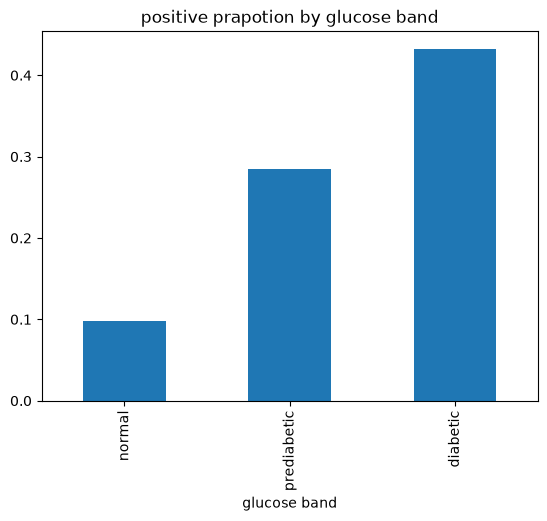

In [116]:
ax=pd.crosstab(df["glucose category"],df["outcome"],normalize="index")[1].plot(kind="bar")
ax.set_xlabel("glucose band")
ax.set_label("prapotion positive")
ax.set_title("positive prapotion by glucose band")
plt.show()

In [117]:
pd.crosstab(df['bmi category'],df['outcome'],normalize='index')

outcome,0,1
bmi category,,
under weights,0.763158,0.236842
normal,0.750000,0.250000
over weight,0.770213,0.229787
obese,0.676311,0.323689


# SAVE YOUR FEATURE-ENGINEERD DATASET

In [118]:
df.to_csv(r"C:\Users\ADMIN\OneDrive\Desktop\5thsem_OJT\project1_diabetes\data\processed/dilna_P1W1_features.csv")